# Discrete water-quality samples: `get_samples`

As USGS retires the legacy NWIS discrete water-quality services, the new
*Water Data for the Nation* samples service takes their place. In Python it is
exposed through three functions in `dataretrieval.waterdata`:

- `get_samples` — retrieve discrete water-quality results (or, with `service=`,
  the matching locations, activities, projects, or organizations).
- `get_samples_summary` — summarize what data a single site has.
- `get_codes` — list the allowable values for the categorical query arguments.

We'll cover retrieving data from a known site, using geographic filters, and
discovering what data are available. The interactive web UI is at
<https://waterdata.usgs.gov/download-samples/> and the API docs are at
<https://api.waterdata.usgs.gov/samples-data/docs>.

> Column names: unlike the OGC `get_daily` / `get_monitoring_locations`
> functions, the samples service uses WQX3-style names such as
> `Location_Latitude`, `Activity_StartDateTime`, and `Result_Measure`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from dataretrieval import waterdata
from dataretrieval.waterdata import PROFILE_LOOKUP

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)


def map_sites(df, title=""):
    """Static scatter plot of sample-site locations. Use folium for interactive."""
    lon = pd.to_numeric(df["Location_Longitude"], errors="coerce")
    lat = pd.to_numeric(df["Location_Latitude"], errors="coerce")
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(lon, lat, s=10, color="red", alpha=0.7)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title} ({len(df)} sites)")
    plt.show()

## Retrieving data from a known site

Given a USGS site, `get_samples_summary` reports what discrete-sample data are
available there — one row per (characteristic group, characteristic,
user-supplied characteristic) with result and activity counts.

In [2]:
site = "USGS-04183500"
data_at_site, _ = waterdata.get_samples_summary(monitoringLocationIdentifier=site)
data_at_site.sort_values("resultCount", ascending=False).head(10)

,monitoringLocationIdentifier,characteristicGroup,characteristic,characteristicUserSupplied,resultCount,activityCount,firstActivity,mostRecentActivity
92,USGS-04183500,Physical,"Stream flow, instantaneous","Discharge, instantaneous",2499,1250,1971-10-05,2026-06-02
87,USGS-04183500,Physical,"Height, gage","Gage height, above datum",2391,1196,2013-10-23,2026-06-02
75,USGS-04183500,Nutrient,Phosphorus,"Phosphorus as phosphorus, water, unfiltered",1287,1287,1969-07-30,2026-05-19
69,USGS-04183500,Nutrient,Organic Nitrogen,"Organic nitrogen as nitrogen, water, unfiltered",1281,1281,1969-07-30,2026-05-19
54,USGS-04183500,Nutrient,Ammonia and ammonium,"Total ammonia (NH4+ and NH3) as ammonium, wate...",1225,1225,1971-10-05,2026-05-19
56,USGS-04183500,Nutrient,Ammonia and ammonium,"Total ammonia (NH4+ and NH3) as nitrogen, wate...",1225,1225,1971-10-05,2026-05-19
70,USGS-04183500,Nutrient,Orthophosphate,"Orthophosphate as orthophosphate, water, filtered",1194,1194,2013-10-23,2026-05-19
71,USGS-04183500,Nutrient,Orthophosphate,"Orthophosphate as phosphorus, water, filtered",1194,1194,2013-10-23,2026-05-19
58,USGS-04183500,Nutrient,Inorganic nitrogen (nitrate and nitrite),"Nitrate plus nitrite as nitrogen, water, filtered",1194,1194,2013-10-23,2026-05-19
60,USGS-04183500,Nutrient,Kjeldahl nitrogen,Total ammonia (NH4+ and NH3) plus organic nitr...,1193,1193,2013-10-23,2026-05-19


Note the `characteristicUserSupplied` column: asking for a bare characteristic
like *Phosphorus* would return both filtered and unfiltered values mixed
together. `characteristicUserSupplied` is a very specific descriptor (similar to
a long-form USGS parameter code) that lets you isolate exactly the constituent
you want. To pull the underlying data, use `get_samples`:

In [3]:
user_char = "Phosphorus as phosphorus, water, unfiltered"
phos_data, _ = waterdata.get_samples(
    monitoringLocationIdentifier=site,
    characteristicUserSupplied=user_char,
)
print(f"default ('fullphyschem') profile -> {phos_data.shape[1]} columns")

default ('fullphyschem') profile -> 187 columns


The default profile (`fullphyschem`, the "Full physical chemical" profile) is
comprehensive, hence the very wide table. For plotting we usually only need a few
columns, so ask for the `narrow` profile instead:

In [4]:
phos_narrow, _ = waterdata.get_samples(
    monitoringLocationIdentifier=site,
    characteristicUserSupplied=user_char,
    profile="narrow",
)
print(f"'narrow' profile -> {phos_narrow.shape[1]} columns")
phos_narrow[["Activity_StartDateTime", "Result_Measure", "Result_MeasureUnit"]].head()

'narrow' profile -> 65 columns


,Activity_StartDateTime,Result_Measure,Result_MeasureUnit
0,1969-07-30 18:30:00+00:00,0.65,mg/L
1,1969-08-06 16:50:00+00:00,0.49,mg/L
2,1969-08-20 15:15:00+00:00,1.80,mg/L
3,1969-09-03 17:37:00+00:00,2.30,mg/L
4,1969-09-18 16:40:00+00:00,2.40,mg/L


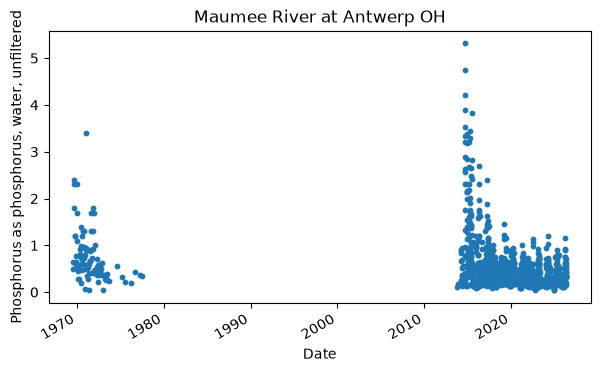

In [5]:
x = pd.to_datetime(phos_narrow["Activity_StartDateTime"], errors="coerce")
y = pd.to_numeric(phos_narrow["Result_Measure"], errors="coerce")
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=10)
ax.set_xlabel("Date")
ax.set_ylabel(user_char, wrap=True)
ax.set_title(phos_narrow["Location_Name"].iloc[0])
fig.autofmt_xdate()
plt.show()

## Return data types

Two arguments control what comes back: `service` defines the *kind* of data and
`profile` defines which columns of that kind are returned. The valid combinations
are published in `PROFILE_LOOKUP`:

In [6]:
PROFILE_LOOKUP

{'activities': ['sampact', 'actmetric', 'actgroup', 'count'],
 'locations': ['site', 'count'],
 'organizations': ['organization', 'count'],
 'projects': ['project', 'projectmonitoringlocationweight'],
 'results': ['fullphyschem',
  'basicphyschem',
  'fullbio',
  'basicbio',
  'narrow',
  'resultdetectionquantitationlimit',
  'labsampleprep',
  'count']}

## Geographic filters

Often you don't know a site number but you do have an area of interest. Below we
keep the queries lightweight by setting `service="locations"` and
`profile="site"` (so we get *where* data exists, not the result values
themselves) and filter on our phosphorus characteristic.

### Bounding box

A bounding box is `[west, south, east, north]` (longitudes then latitudes):

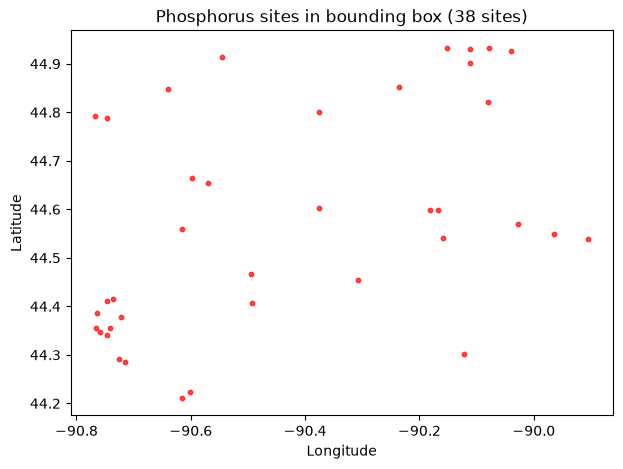

In [7]:
bbox = [-90.8, 44.2, -89.9, 45.0]
bbox_sites, _ = waterdata.get_samples(
    boundingBox=bbox,
    characteristicUserSupplied=user_char,
    service="locations",
    profile="site",
)
map_sites(bbox_sites, "Phosphorus sites in bounding box")

### Hydrologic unit codes (HUCs)

HUCs identify drainage areas; this filter accepts 2-, 4-, 6-, 8-, 10-, or
12-digit codes.

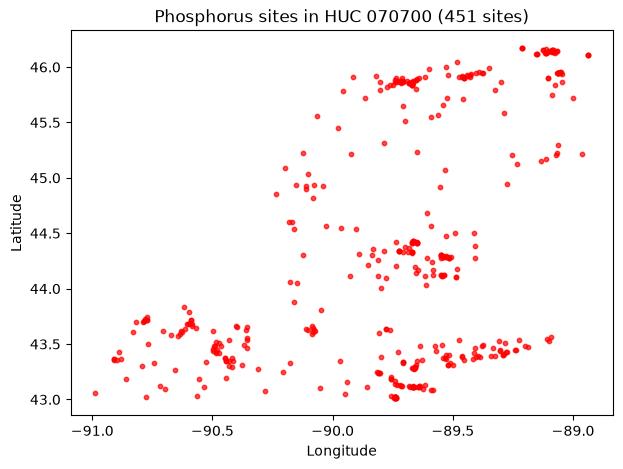

In [8]:
huc_sites, _ = waterdata.get_samples(
    hydrologicUnit="070700",
    characteristicUserSupplied=user_char,
    service="locations",
    profile="site",
)
map_sites(huc_sites, "Phosphorus sites in HUC 070700")

### Distance from a point

Supply a latitude, longitude, and radius in miles:

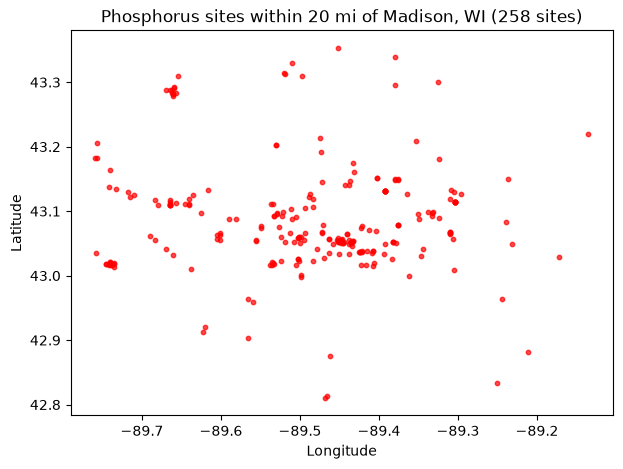

In [9]:
point_sites, _ = waterdata.get_samples(
    pointLocationLatitude=43.074680,
    pointLocationLongitude=-89.428054,
    pointLocationWithinMiles=20,
    characteristicUserSupplied=user_char,
    service="locations",
    profile="site",
)
map_sites(point_sites, "Phosphorus sites within 20 mi of Madison, WI")

### County FIPS

County FIPS codes take the form `US:SS:CCC`. Wisconsin's state code is available
from `dataretrieval.codes`, and Dane County's full FIPS is `US:55:025`.

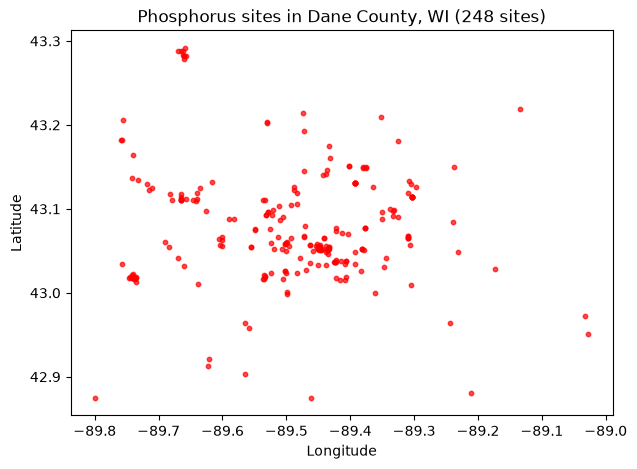

In [10]:
from dataretrieval.codes import states

wi = states.fips_codes["Wisconsin"]  # "55"
dane_county = f"US:{wi}:025"
county_sites, _ = waterdata.get_samples(
    countyFips=dane_county,
    characteristicUserSupplied=user_char,
    service="locations",
    profile="site",
)
map_sites(county_sites, "Phosphorus sites in Dane County, WI")

### State FIPS

State FIPS codes take the form `US:SS`. A whole-state query can return a lot of
sites, so here we also constrain the activity start date to October–November 2024
(see *Additional query parameters* below):

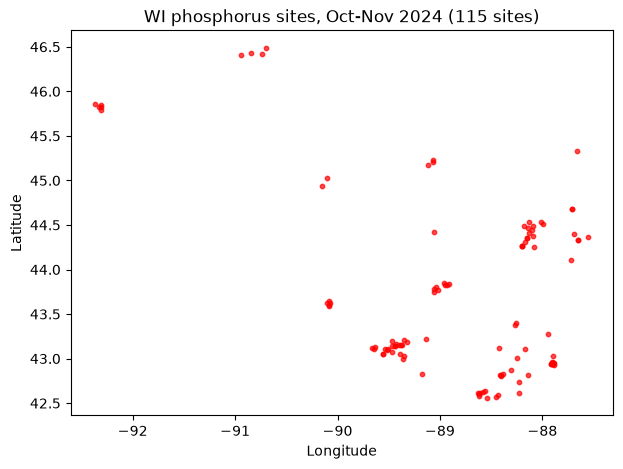

In [11]:
state_fip = f"US:{wi}"  # "US:55"
state_sites_recent, _ = waterdata.get_samples(
    stateFips=state_fip,
    characteristicUserSupplied=user_char,
    service="locations",
    activityStartDateLower="2024-10-01",
    activityStartDateUpper="2024-11-30",
    profile="site",
)
map_sites(state_sites_recent, "WI phosphorus sites, Oct-Nov 2024")

## Additional query parameters

Several parameters narrow the results further. The allowable values for the
categorical ones come from `get_codes`, which — like the other `waterdata`
functions — returns a `(DataFrame, metadata)` tuple; we unpack it and keep the
DataFrame.

### `siteTypeCode` / `siteTypeName`

In [12]:
site_type_info, _ = waterdata.get_codes(code_service="sitetype")
site_type_info[["typeCode", "typeLongName"]].head(10)

,typeCode,typeLongName
0,GL,Glacier
1,WE,Wetland
2,LA,Land
3,LA-EX,Excavation
4,LA-OU,Outcrop
5,LA-PLY,Playa
6,LA-SNK,Sinkhole
7,LA-SH,Soil hole
8,LA-SR,Shore
9,LA-VOL,Volcanic vent


### `activityMediaName`

The environmental medium that was sampled or analyzed:

In [13]:
media, _ = waterdata.get_codes(code_service="samplemedia")
media["activityMedia"].tolist()

['Air', 'Biological tissue', 'Other', 'Sediment', 'Soil', 'Water', nan]

### `characteristicGroup`

A broad category describing the measurement (generally following the Water
Quality Portal groups):

In [14]:
char_groups, _ = waterdata.get_codes(code_service="characteristicgroup")
char_groups["characteristicGroup"].tolist()

['Biological',
 'Information',
 'Inorganics, Major, Metals',
 'Inorganics, Major, Non-metals',
 'Inorganics, Minor, Metals',
 'Inorganics, Minor, Non-metals',
 'Microbiological',
 'Nutrient',
 'Organics, Other',
 'Organics, PCBs',
 'Organics, Pesticide',
 'Organics, PFAS',
 'Physical',
 'Population/Community',
 'Radiochemical',
 'Sediment',
 'Stable Isotopes',
 'Toxicity']

### `characteristic` and `usgsPCode`

The `characteristics` table lists specific constituents along with their USGS
parameter codes:

In [15]:
characteristic_info, _ = waterdata.get_codes(code_service="characteristics")
print("unique characteristic names:")
print(characteristic_info["characteristicName"].drop_duplicates().head().tolist())
print("\nexample USGS parameter codes:")
print(characteristic_info["parameterCode"].dropna().drop_duplicates().head().tolist())

unique characteristic names:
['Hydroxy-amitriptyline, 10-', '1,1,1,2-Tetrachloroethane', '1,1,1-Trichloro-2-propanone', '1,1,1-Trichloroethane', '1,1,2,2-Tetrachloroethane']

example USGS parameter codes:
['67995', '52417', '30089', '62235', '77562']


### `characteristicUserSupplied`

The USGS "observed property" — the detailed descriptor that replaces the old
parameter name / pcode for discrete data, and the value we filtered on above:

In [16]:
observed, _ = waterdata.get_codes(code_service="observedproperty")
observed["observedProperty"].head().tolist()

['10-Hydroxy-amitriptyline, water, filtered, recoverable',
 '1,1,1,2-Tetrachloroethane, bed sediment (dry mass basis), recoverable',
 '1,1,1,2-Tetrachloroethane, soil (dry mass basis), recoverable',
 '1,1,1,2-Tetrachloroethane, water, unfiltered, recoverable',
 '1,1,1-Trichloro-2-propanone, water, filtered, recoverable']

Other filters worth knowing about: `projectIdentifier` (needs prior project
info), `recordIdentifierUserSupplied` (needs the supplier's record id), and
`activityStartDateLower` / `activityStartDateUpper` for date ranges (used above).

## Data discovery

Combining a geographic filter with site-type and characteristic filters lets you
zero in on candidate sites. For example, lakes in Dane County, WI that measured
our phosphorus characteristic:

In [17]:
county_lake_sites, _ = waterdata.get_samples(
    countyFips=dane_county,
    characteristicUserSupplied=user_char,
    siteTypeName="Lake, Reservoir, Impoundment",
    service="locations",
    profile="site",
)
print(f"{len(county_lake_sites)} lake sites measuring phosphorus in Dane County, WI")

18 lake sites measuring phosphorus in Dane County, WI


`get_samples_summary` accepts one site at a time, so we loop over the candidate
sites to tally how much phosphorus data each has — useful for deciding which
sites to actually pull results from.

In [18]:
rows = []
for loc_id in county_lake_sites["Location_Identifier"]:
    avail, _ = waterdata.get_samples_summary(monitoringLocationIdentifier=loc_id)
    rows.append(avail[avail["characteristicUserSupplied"] == user_char])

all_data = pd.concat(rows, ignore_index=True)
all_data.sort_values("resultCount", ascending=False)[
    [
        "monitoringLocationIdentifier",
        "resultCount",
        "activityCount",
        "firstActivity",
        "mostRecentActivity",
    ]
]

,monitoringLocationIdentifier,resultCount,activityCount,firstActivity,mostRecentActivity
13,USGS-430309089260701,159,159,1986-06-28,1995-04-07
2,USGS-054279449,96,96,1998-02-12,1998-08-23
10,USGS-430117089442701,49,49,1992-05-21,1993-09-24
5,USGS-430307089260200,49,49,1986-09-28,1988-04-05
12,USGS-430305089260600,32,32,1986-11-22,1987-12-08
0,USGS-05427946,12,12,1981-09-02,1982-08-12
1,USGS-054279485,12,12,1981-09-02,1982-08-12
3,USGS-05427949,12,12,1981-09-02,1982-08-12
9,USGS-430113089320101,6,6,1975-03-22,1976-05-31
15,USGS-430325089361601,5,5,1975-05-16,1976-05-19


This summary helps narrow down which sites to request data from — whether you
need sites with recent data, lots of data, or just any measurement at all.

## More help

- Documentation: <https://doi-usgs.github.io/dataretrieval-python/>
- Samples API docs: <https://api.waterdata.usgs.gov/samples-data/docs>
- Equivalent R article: [Introducing read_waterdata_samples](https://doi-usgs.github.io/dataRetrieval/articles/samples_data.html)
- Issues / questions: <https://github.com/DOI-USGS/dataretrieval-python/issues>